## Age Effect Analysis
### Comparing Converters vs Non-Converters Before and After Age Regression

This notebook investigates how much of the observed group differences can be attributed to age confounds.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('/mnt/e/fyassine/ad-early-detection')
import config

from edges_utils_lib import run_network_analysis, run_diagnostic_tests
from import_utils import load_and_process_cohorts
from age_utils import load_subject_ages, get_aligned_ages, regress_out_covariate

### 1. Load Data and Ages

In [2]:
cohorts_raw = load_and_process_cohorts(config, correlation_type="pearson", remove_nan=True)
age_map = load_subject_ages()
print(f"Loaded {len(age_map)} subject ages")

Healthy: 201 subjects, Matrix shape: (201, 110, 110), Edges shape: (201, 5995)
AD: 104 subjects, Matrix shape: (104, 110, 110), Edges shape: (104, 5995)
MCI: 533 subjects, Matrix shape: (533, 110, 110), Edges shape: (533, 5995)
Converters: 60 subjects, Matrix shape: (60, 110, 110), Edges shape: (60, 5995)
[age_utils] Example IDs from CSV: ['93f563391', '043ba1305', '157dec7d5', '5598d51dd', '8a025f647']
Loaded 937 subject ages


In [3]:
converters = cohorts_raw['converter']
non_converters = {
    'name': 'Non-Converters',
    'ids': np.concatenate([cohorts_raw['healthy']['ids'], cohorts_raw['mci']['ids']]),
    'edges': np.vstack([cohorts_raw['healthy']['edges'], cohorts_raw['mci']['edges']])
}

conv_ids = converters['ids']
conv_edges = converters['edges']
non_conv_ids = non_converters['ids']
non_conv_edges = non_converters['edges']

print(f"Converters: {len(conv_ids)} subjects")
print(f"Non-Converters: {len(non_conv_ids)} subjects")

Converters: 60 subjects
Non-Converters: 734 subjects


### 2. Analyze Age Distribution by Group

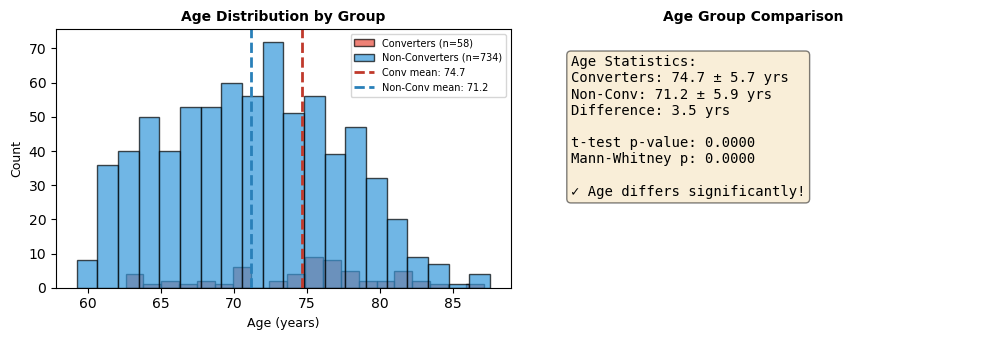

In [4]:
conv_ages = get_aligned_ages(conv_ids, age_map)
non_conv_ages = get_aligned_ages(non_conv_ids, age_map)

conv_ages_valid = conv_ages[~np.isnan(conv_ages)]
non_conv_ages_valid = non_conv_ages[~np.isnan(non_conv_ages)]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].hist(conv_ages_valid, bins=20, alpha=0.7, label=f'Converters (n={len(conv_ages_valid)})', color='#e74c3c', edgecolor='black')
axes[0].hist(non_conv_ages_valid, bins=20, alpha=0.7, label=f'Non-Converters (n={len(non_conv_ages_valid)})', color='#3498db', edgecolor='black')
axes[0].axvline(np.mean(conv_ages_valid), color='#c0392b', linestyle='--', linewidth=2, label=f'Conv mean: {np.mean(conv_ages_valid):.1f}')
axes[0].axvline(np.mean(non_conv_ages_valid), color='#2980b9', linestyle='--', linewidth=2, label=f'Non-Conv mean: {np.mean(non_conv_ages_valid):.1f}')
axes[0].set_xlabel('Age (years)', fontsize=9)
axes[0].set_ylabel('Count', fontsize=9)
axes[0].set_title('Age Distribution by Group', fontsize=10, fontweight='bold')
axes[0].legend(fontsize=7)

from scipy.stats import ttest_ind, mannwhitneyu
t_stat, t_pval = ttest_ind(conv_ages_valid, non_conv_ages_valid)
u_stat, u_pval = mannwhitneyu(conv_ages_valid.flatten(), non_conv_ages_valid.flatten())

stats_text = f"Age Statistics:\n"
stats_text += f"Converters: {np.mean(conv_ages_valid):.1f} ± {np.std(conv_ages_valid):.1f} yrs\n"
stats_text += f"Non-Conv: {np.mean(non_conv_ages_valid):.1f} ± {np.std(non_conv_ages_valid):.1f} yrs\n"
stats_text += f"Difference: {np.mean(conv_ages_valid) - np.mean(non_conv_ages_valid):.1f} yrs\n\n"
stats_text += f"t-test p-value: {t_pval:.4f}\n"
stats_text += f"Mann-Whitney p: {u_pval:.4f}\n\n"
stats_text += f"{'✓ Age differs significantly!' if t_pval < 0.05 else '✗ No significant age difference'}"

axes[1].axis('off')
axes[1].text(0.1, 0.9, stats_text, transform=axes[1].transAxes, fontsize=10, va='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1].set_title('Age Group Comparison', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

**Interpretation:** If the groups differ significantly in age, the observed connectivity differences may be confounded by age effects. We need to regress out age to isolate the true group differences.

### 3. Run Tests BEFORE Age Regression (Baseline)

In [5]:
cohorts_before = {
    "converters": {"name": "Converters", "ids": conv_ids, "edges": conv_edges},
    "non_converters": {"name": "Non Converters", "ids": non_conv_ids, "edges": non_conv_edges}
}

results_before = run_network_analysis(
    cohorts_before, 
    group_a="converters", 
    group_b="non_converters", 
    nbs_threshold=3.0, 
    n_perms=5000,
    run_permanova=True,
    run_nbs=True
)

diag_before = run_diagnostic_tests(cohorts_before, group_a="converters", group_b="non_converters", plot=False)

print("=== BEFORE Age Regression ===")
print(f"PERMANOVA p-value: {results_before['permanova']['p_value']:.4f}")
print(f"PERMANOVA R²: {results_before['permanova']['r_squared']*100:.2f}%")
print(f"NBS significant components: {len(results_before['nbs']['significant_components'])}")
print(f"FDR significant edges: {diag_before['sig_fdr_count']} ({diag_before['sig_fdr_pct']:.2f}%)")

=== BEFORE Age Regression ===
PERMANOVA p-value: 0.0002
PERMANOVA R²: 0.22%
NBS significant components: 1
FDR significant edges: 16 (0.27%)


### 4. Regress Out Age and Re-run Tests

In [6]:
all_ids = np.concatenate([conv_ids, non_conv_ids])
all_edges = np.vstack([conv_edges, non_conv_edges])
all_ages = get_aligned_ages(all_ids, age_map)

edges_residuals, valid_mask = regress_out_covariate(all_edges, all_ages)

n_conv = len(conv_ids)
valid_indices = np.where(valid_mask)[0]
conv_valid_mask = valid_indices < n_conv
non_conv_valid_mask = valid_indices >= n_conv

conv_edges_corrected = edges_residuals[conv_valid_mask]
non_conv_edges_corrected = edges_residuals[non_conv_valid_mask]
conv_ids_corrected = np.array([all_ids[i] for i in valid_indices if i < n_conv])
non_conv_ids_corrected = np.array([all_ids[i] for i in valid_indices if i >= n_conv])

print(f"After removing subjects with missing age:")
print(f"  Converters: {len(conv_ids_corrected)} subjects")
print(f"  Non-Converters: {len(non_conv_ids_corrected)} subjects")

Dropping 2 subjects due to missing covariates.
After removing subjects with missing age:
  Converters: 58 subjects
  Non-Converters: 734 subjects


In [7]:
cohorts_after = {
    "converters": {"name": "Converters", "ids": conv_ids_corrected, "edges": conv_edges_corrected},
    "non_converters": {"name": "Non Converters", "ids": non_conv_ids_corrected, "edges": non_conv_edges_corrected}
}

results_after = run_network_analysis(
    cohorts_after, 
    group_a="converters", 
    group_b="non_converters", 
    nbs_threshold=3.0, 
    n_perms=5000,
    run_permanova=True,
    run_nbs=True
)

diag_after = run_diagnostic_tests(cohorts_after, group_a="converters", group_b="non_converters", plot=False)

print("=== AFTER Age Regression ===")
print(f"PERMANOVA p-value: {results_after['permanova']['p_value']:.4f}")
print(f"PERMANOVA R²: {results_after['permanova']['r_squared']*100:.2f}%")
print(f"NBS significant components: {len(results_after['nbs']['significant_components'])}")
print(f"FDR significant edges: {diag_after['sig_fdr_count']} ({diag_after['sig_fdr_pct']:.2f}%)")

=== AFTER Age Regression ===
PERMANOVA p-value: 0.0072
PERMANOVA R²: 0.18%
NBS significant components: 1
FDR significant edges: 0 (0.00%)


### 5. Compare Results: Before vs After Age Regression

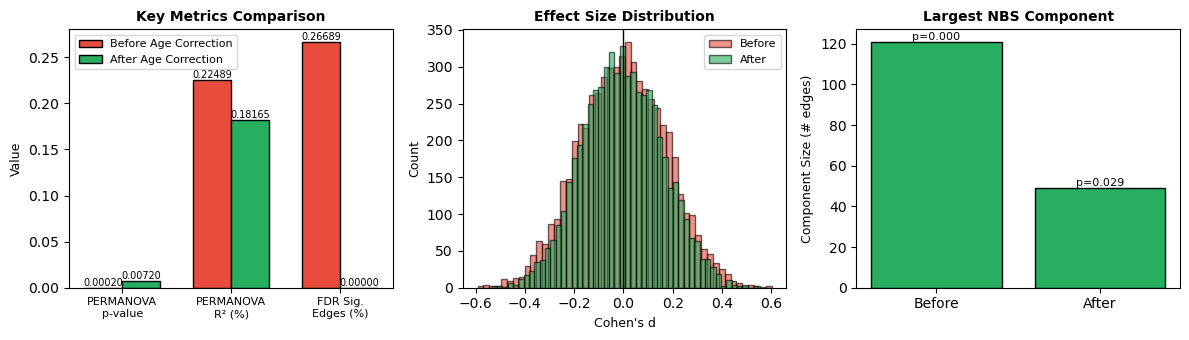

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

metrics = ['PERMANOVA\np-value', 'PERMANOVA\nR² (%)', 'FDR Sig.\nEdges (%)']
before_vals = [results_before['permanova']['p_value'], 
               results_before['permanova']['r_squared']*100, 
               diag_before['sig_fdr_pct']]
after_vals = [results_after['permanova']['p_value'], 
              results_after['permanova']['r_squared']*100, 
              diag_after['sig_fdr_pct']]

x = np.arange(len(metrics))
width = 0.35

bars1 = axes[0].bar(x - width/2, before_vals, width, label='Before Age Correction', color='#e74c3c', edgecolor='black')
bars2 = axes[0].bar(x + width/2, after_vals, width, label='After Age Correction', color='#27ae60', edgecolor='black')

axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics, fontsize=8)
axes[0].set_ylabel('Value', fontsize=9)
axes[0].set_title('Key Metrics Comparison', fontsize=10, fontweight='bold')
axes[0].legend(fontsize=8)

for bar, val in zip(bars1, before_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:.5f}', ha='center', va='bottom', fontsize=7)
for bar, val in zip(bars2, after_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:.5f}', ha='center', va='bottom', fontsize=7)

cohens_before = diag_before['cohens_d']
cohens_after = diag_after['cohens_d']

axes[1].hist(cohens_before, bins=50, alpha=0.6, label='Before', color='#e74c3c', edgecolor='black')
axes[1].hist(cohens_after, bins=50, alpha=0.6, label='After', color='#27ae60', edgecolor='black')
axes[1].axvline(0, color='black', linestyle='-', linewidth=1)
axes[1].set_xlabel("Cohen's d", fontsize=9)
axes[1].set_ylabel('Count', fontsize=9)
axes[1].set_title('Effect Size Distribution', fontsize=10, fontweight='bold')
axes[1].legend(fontsize=8)

nbs_before_size = results_before['nbs']['all_components'][0]['size'] if results_before['nbs']['all_components'] else 0
nbs_after_size = results_after['nbs']['all_components'][0]['size'] if results_after['nbs']['all_components'] else 0
nbs_before_p = results_before['nbs']['all_components'][0]['p_value'] if results_before['nbs']['all_components'] else 1
nbs_after_p = results_after['nbs']['all_components'][0]['p_value'] if results_after['nbs']['all_components'] else 1

nbs_labels = ['Before', 'After']
nbs_sizes = [nbs_before_size, nbs_after_size]
nbs_colors = ['#27ae60' if nbs_before_p < 0.05 else '#e74c3c', '#27ae60' if nbs_after_p < 0.05 else '#e74c3c']

bars = axes[2].bar(nbs_labels, nbs_sizes, color=nbs_colors, edgecolor='black')
axes[2].set_ylabel('Component Size (# edges)', fontsize=9)
axes[2].set_title('Largest NBS Component', fontsize=10, fontweight='bold')

for bar, p in zip(bars, [nbs_before_p, nbs_after_p]):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'p={p:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

**Interpretation:** Compare the metrics before and after age regression. A decrease in significance suggests age was confounding the results. If results remain significant, the group differences are independent of age.

### 6. Summary: Age Effect Analysis

In [9]:
perm_p_change = ((results_after['permanova']['p_value'] - results_before['permanova']['p_value']) / results_before['permanova']['p_value']) * 100
r2_change = results_after['permanova']['r_squared'] - results_before['permanova']['r_squared']
fdr_change = diag_after['sig_fdr_count'] - diag_before['sig_fdr_count']
effect_change = diag_after['median_effect_size'] - diag_before['median_effect_size']

summary = f"""
{'='*65}
              AGE EFFECT ANALYSIS SUMMARY
{'='*65}

AGE DISTRIBUTION
  Converters mean age:     {np.mean(conv_ages_valid):.1f} ± {np.std(conv_ages_valid):.1f} years
  Non-Converters mean age: {np.mean(non_conv_ages_valid):.1f} ± {np.std(non_conv_ages_valid):.1f} years
  Age difference p-value:  {t_pval:.4f} {'(SIGNIFICANT)' if t_pval < 0.05 else '(not significant)'}

PERMANOVA RESULTS
                          BEFORE          AFTER           CHANGE
  p-value:                {results_before['permanova']['p_value']:.4f}          {results_after['permanova']['p_value']:.4f}          {perm_p_change:+.1f}%
  R² (variance):          {results_before['permanova']['r_squared']*100:.2f}%          {results_after['permanova']['r_squared']*100:.2f}%          {r2_change*100:+.3f}%

NETWORK-BASED STATISTIC (NBS)
  Largest component:      {nbs_before_size} edges       {nbs_after_size} edges       {nbs_after_size - nbs_before_size:+d}
  Component p-value:      {nbs_before_p:.4f}          {nbs_after_p:.4f}
  Significant components: {len(results_before['nbs']['significant_components'])}               {len(results_after['nbs']['significant_components'])}

EDGE-WISE ANALYSIS
  FDR significant edges:  {diag_before['sig_fdr_count']}              {diag_after['sig_fdr_count']}              {fdr_change:+d}
  Median effect |d|:      {diag_before['median_effect_size']:.3f}           {diag_after['median_effect_size']:.3f}           {effect_change:+.3f}

{'='*65}
INTERPRETATION:
"""

if results_after['permanova']['p_value'] < 0.05:
    if results_before['permanova']['p_value'] < 0.05:
        summary += "  ✓ Group differences REMAIN SIGNIFICANT after age correction.\n"
        summary += "    The connectivity differences are largely independent of age.\n"
    else:
        summary += "  ! Group differences BECAME SIGNIFICANT after age correction.\n"
        summary += "    Age was masking true group differences.\n"
else:
    if results_before['permanova']['p_value'] < 0.05:
        summary += "  ✗ Group differences LOST SIGNIFICANCE after age correction.\n"
        summary += "    Age was a major confound in the observed differences.\n"
    else:
        summary += "  ✗ No significant differences before or after age correction.\n"

if t_pval < 0.05:
    summary += f"\n  Note: Groups differ significantly in age ({np.mean(conv_ages_valid):.1f} vs {np.mean(non_conv_ages_valid):.1f} years),\n"
    summary += "        making age correction important for valid inference.\n"

summary += f"{'='*65}"

print(summary)


              AGE EFFECT ANALYSIS SUMMARY

AGE DISTRIBUTION
  Converters mean age:     74.7 ± 5.7 years
  Non-Converters mean age: 71.2 ± 5.9 years
  Age difference p-value:  0.0000 (SIGNIFICANT)

PERMANOVA RESULTS
                          BEFORE          AFTER           CHANGE
  p-value:                0.0002          0.0072          +3500.0%
  R² (variance):          0.22%          0.18%          -0.043%

NETWORK-BASED STATISTIC (NBS)
  Largest component:      121 edges       49 edges       -72
  Component p-value:      0.0000          0.0294
  Significant components: 1               1

EDGE-WISE ANALYSIS
  FDR significant edges:  16              0              -16
  Median effect |d|:      0.123           0.112           -0.011

INTERPRETATION:
  ✓ Group differences REMAIN SIGNIFICANT after age correction.
    The connectivity differences are largely independent of age.

  Note: Groups differ significantly in age (74.7 vs 71.2 years),
        making age correction important for va